Prix de l'Option Asiatique: 3.5063 (+/- 0.0302)


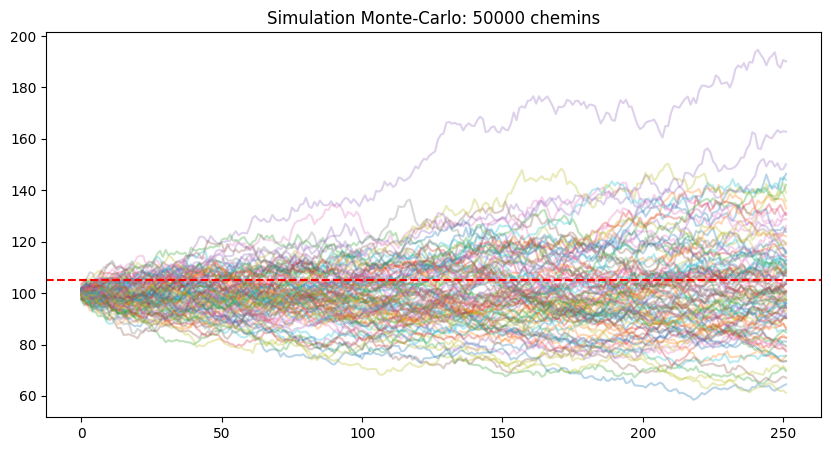

np.float64(3.5063110002823556)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class AsianOptionPricer:
    def __init__(self, S0=100, K=105, T=1, r=0.05, sigma=0.2, n_paths=50000):
        self.S0, self.K, self.T, self.r, self.sigma = S0, K, T, r, sigma
        self.n_paths = n_paths
        self.steps = 252 # Un an de jours de trading

    def generate_paths(self):
        dt = self.T / self.steps
        # Utilisation de variables antithétiques pour réduire la variance
        z = np.random.standard_normal((self.n_paths // 2, self.steps))
        z = np.concatenate([z, -z], axis=0)
        
        drift = (self.r - 0.5 * self.sigma**2) * dt
        diffusion = self.sigma * np.sqrt(dt) * z
        daily_returns = np.exp(drift + diffusion)
        
        # Chemins de prix : S0 * produit cumulé des rendements
        paths = self.S0 * np.cumprod(daily_returns, axis=1)
        return paths

    def price(self):
        paths = self.generate_paths()
        # Option Asiatique : Payoff basé sur la MOYENNE arithmétique
        avg_prices = np.mean(paths, axis=1)
        payoffs = np.maximum(avg_prices - self.K, 0)
        
        price = np.exp(-self.r * self.T) * np.mean(payoffs)
        std_err = np.std(payoffs) / np.sqrt(self.n_paths)
        
        print(f"Prix de l'Option Asiatique: {price:.4f} (+/- {std_err:.4f})")
        
        # Plot des 100 premières trajectoires
        plt.figure(figsize=(10, 5))
        plt.plot(paths[:100].T, alpha=0.3)
        plt.axhline(self.K, color='red', linestyle='--', label='Strike')
        plt.title(f"Simulation Monte-Carlo: {self.n_paths} chemins")
        plt.show()
        
        return price

# Teste-le directement :
pricer = AsianOptionPricer()
pricer.price()